In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df = pd.read_csv("../data/raw/turkey_rent.csv", low_memory=False)
df.head()

,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,...,Eşya Durumu,Takas,Yapı Tipi,Aidat,Depozito,Görüntülü Gezilebilir mi?,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
0,17931647.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,100 m²,120 m²,2+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17927211.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,140 m²,175 m²,3+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17928161.0,21 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,75 m²,100 m²,1+1,5-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17940270.0,23 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,45 m²,50 m²,1+1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17937078.0,22 Ağustos 2025,22 Ağustos 2025,Konut,Kiralık,Daire,185 m²,200 m²,4+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Clear

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28259 entries, 0 to 28258
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   İlan Numarası              28235 non-null  float64
 1   İlan Oluşturma Tarihi      28235 non-null  object 
 2   İlan Güncelleme Tarihi     28235 non-null  object 
 3   Türü                       28235 non-null  object 
 4   Kategorisi                 28235 non-null  object 
 5   Tipi                       28235 non-null  object 
 6   Net Metrekare              28235 non-null  object 
 7   Brüt Metrekare             28235 non-null  object 
 8   Oda Sayısı                 28235 non-null  object 
 9   Binanın Yaşı               28235 non-null  object 
 10  Bulunduğu Kat              28235 non-null  object 
 11  Binanın Kat Sayısı         28235 non-null  float64
 12  Isıtma Tipi                28235 non-null  object 
 13  Kullanım Durumu            28235 non-null  obj

In [156]:
df.duplicated().sum()

np.int64(979)

In [157]:
df[df.duplicated()]

,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,...,Eşya Durumu,Takas,Yapı Tipi,Aidat,Depozito,Görüntülü Gezilebilir mi?,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
1316,17931647.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,100 m²,120 m²,2+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1317,17927211.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,140 m²,175 m²,3+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1318,17928161.0,21 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,75 m²,100 m²,1+1,5-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1319,17940270.0,23 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,45 m²,50 m²,1+1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1320,17937078.0,22 Ağustos 2025,22 Ağustos 2025,Konut,Kiralık,Daire,185 m²,200 m²,4+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25261,17520614.0,21 Haziran 2025,10 Temmuz 2025,Konut,Kiralık,Daire,110 m²,180 m²,3+1,16-20,...,NaN,Yok,Betonarme,150 TL,NaN,NaN,NaN,NaN,NaN,NaN
25538,17922371.0,20 Ağustos 2025,20 Ağustos 2025,Konut,Kiralık,Daire,50 m²,65 m²,1+1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25826,17523659.0,21 Haziran 2025,21 Haziran 2025,Konut,Kiralık,Daire,50 m²,64 m²,2+0,0 (Yeni),...,NaN,NaN,NaN,NaN,11000 TL,NaN,NaN,NaN,NaN,NaN
26082,17855921.0,13 Ağustos 2025,19 Ağustos 2025,Konut,Kiralık,Daire,75 m²,90 m²,2+1,0 (Yeni),...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
df[df.duplicated(keep=False)]

,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,...,Eşya Durumu,Takas,Yapı Tipi,Aidat,Depozito,Görüntülü Gezilebilir mi?,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
0,17931647.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,100 m²,120 m²,2+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17927211.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,140 m²,175 m²,3+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17928161.0,21 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,75 m²,100 m²,1+1,5-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17940270.0,23 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,45 m²,50 m²,1+1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17937078.0,22 Ağustos 2025,22 Ağustos 2025,Konut,Kiralık,Daire,185 m²,200 m²,4+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25826,17523659.0,21 Haziran 2025,21 Haziran 2025,Konut,Kiralık,Daire,50 m²,64 m²,2+0,0 (Yeni),...,NaN,NaN,NaN,NaN,11000 TL,NaN,NaN,NaN,NaN,NaN
26051,17855921.0,13 Ağustos 2025,19 Ağustos 2025,Konut,Kiralık,Daire,75 m²,90 m²,2+1,0 (Yeni),...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26082,17855921.0,13 Ağustos 2025,19 Ağustos 2025,Konut,Kiralık,Daire,75 m²,90 m²,2+1,0 (Yeni),...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26881,17449464.0,04 Haziran 2025,10 Haziran 2025,Konut,Kiralık,Daire,50 m²,60 m²,1+1,0 (Yeni),...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
print("Kaç satır var : ", len(df))
df = df.drop_duplicates()
print("Kaç satır var : ", len(df))

Kaç satır var :  28259
Kaç satır var :  27280


In [160]:
df["Türü"].unique()

array(['Konut', nan], dtype=object)

In [161]:
df[df["Fiyat Durumu"] == "Birim Fiyat"]["URL"]

6        https://www.emlakjet.com/ilan/aydinlar-mahalle...
7        https://www.emlakjet.com/ilan/baraj-yolu-civar...
9        https://www.emlakjet.com/ilan/kacmaz-ful-dogal...
12       https://www.emlakjet.com/ilan/beyaz-evler-maha...
15       https://www.emlakjet.com/ilan/baraj-yolu-civar...
                               ...                        
28148    https://www.emlakjet.com/ilan/erol-emlak-tan-m...
28152    https://www.emlakjet.com/ilan/kendi-sahibinden...
28201    https://www.emlakjet.com/ilan/kepez-sec-market...
28222    https://www.emlakjet.com/ilan/sahibinden-araka...
28254    https://www.emlakjet.com/ilan/hayvansevere-kir...
Name: URL, Length: 581, dtype: object

In [162]:
df["Türü"]

0        Konut
1        Konut
2        Konut
3        Konut
4        Konut
         ...  
28254    Konut
28255    Konut
28256    Konut
28257    Konut
28258    Konut
Name: Türü, Length: 27280, dtype: object

In [163]:
df["Balkon Durumu"].value_counts()

Balkon Durumu
Var    4269
Yok     690
Name: count, dtype: int64

In [164]:
df.nunique()

İlan Numarası                27232
İlan Oluşturma Tarihi          633
İlan Güncelleme Tarihi         110
Türü                             1
Kategorisi                       1
Tipi                             1
Net Metrekare                  239
Brüt Metrekare                 279
Oda Sayısı                      26
Binanın Yaşı                     9
Bulunduğu Kat                   43
Binanın Kat Sayısı              36
Isıtma Tipi                     21
Kullanım Durumu                  3
Tapu Durumu                     10
Site İçerisinde                  2
Banyo Sayısı                     7
Balkon Durumu                    2
Balkon Sayısı                    4
Balkon Tipi                     18
WC Sayısı                        9
Fiyat Durumu                     2
fiyat                          556
konum                         4623
URL                          27256
Ada                           4134
Parsel                         693
Yapı Durumu                      3
Eşya Durumu         

In [165]:
df["Fiyat Durumu"].unique()

array(['Genel Fiyat', 'Birim Fiyat', nan], dtype=object)

**Gereksiz gördüğüm sütunları kaldırıyorum.**
- "İlan Oluşturma Tarihi" : ilanın oluşturulma tarihi
- "İlan Güncelleme Tarihi" : 
- "İlan Numarası" : tahmin için bir anlam ifade etmiyor
- "URL" : tahmin için bir anlam ifade etmiyor
- "Ada" :
- "Parsel" :
- "Fiyat Durumu" : anlamlı olabilir ancak sitede düzgün kullanıldığını düşünmüyorum. 
- "Görüntülü Gezilebilir mi?" : kira fiyatı için önemli değil
- Tipi : önemli ancak bizim veri setinde sadece "Daire" var. Tekrar ediyor 
- Türü : sadece "Konut" değeri var
- "Kategorisi" : sadece kiralık değeri var



In [166]:
len(df.columns)

38

In [167]:
df1 = df.drop(columns=["İlan Oluşturma Tarihi", "İlan Güncelleme Tarihi", "İlan Numarası", "URL", "Ada", "Parsel", "Fiyat Durumu", "Görüntülü Gezilebilir mi?", "Tipi", "Türü", "Kategorisi"])
len(df1.columns)

27

In [168]:
df1.columns

Index(['Net Metrekare', 'Brüt Metrekare', 'Oda Sayısı', 'Binanın Yaşı',
       'Bulunduğu Kat', 'Binanın Kat Sayısı', 'Isıtma Tipi', 'Kullanım Durumu',
       'Tapu Durumu', 'Site İçerisinde', 'Banyo Sayısı', 'Balkon Durumu',
       'Balkon Sayısı', 'Balkon Tipi', 'WC Sayısı', 'fiyat', 'konum',
       'Yapı Durumu', 'Eşya Durumu', 'Takas', 'Yapı Tipi', 'Aidat', 'Depozito',
       'Banyo Metrekare', 'Balkon Metrekare', 'Salon Metrekare',
       'WC Metrekare '],
      dtype='object')

In [169]:
df.head()

,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,...,Eşya Durumu,Takas,Yapı Tipi,Aidat,Depozito,Görüntülü Gezilebilir mi?,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
0,17931647.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,100 m²,120 m²,2+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17927211.0,21 Ağustos 2025,21 Ağustos 2025,Konut,Kiralık,Daire,140 m²,175 m²,3+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17928161.0,21 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,75 m²,100 m²,1+1,5-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17940270.0,23 Ağustos 2025,23 Ağustos 2025,Konut,Kiralık,Daire,45 m²,50 m²,1+1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17937078.0,22 Ağustos 2025,22 Ağustos 2025,Konut,Kiralık,Daire,185 m²,200 m²,4+1,16-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Sonuç : Verisetindeki işimize yaramayacak sütunları kaldırdık. Tekrar eden rowlar temizledik.**

# Handling Missing Data

In [170]:
df1.isnull().sum()

Net Metrekare            24
Brüt Metrekare           24
Oda Sayısı               24
Binanın Yaşı             24
Bulunduğu Kat            24
Binanın Kat Sayısı       24
Isıtma Tipi              24
Kullanım Durumu          24
Tapu Durumu              24
Site İçerisinde          24
Banyo Sayısı             24
Balkon Durumu         22321
Balkon Sayısı         23963
Balkon Tipi           24773
WC Sayısı             23972
fiyat                    24
konum                    24
Yapı Durumu           23094
Eşya Durumu            7498
Takas                  8244
Yapı Tipi             23380
Aidat                 23756
Depozito              22796
Banyo Metrekare       26599
Balkon Metrekare      26602
Salon Metrekare       26765
WC Metrekare          26884
dtype: int64

Sütunlardaki boş verilerin oranı bulur

In [171]:
def bos_veri_orani(df):
    return round((df.isnull().sum() / df.shape[0])*100, 2)

In [172]:
bos_veri_orani(df1)

Net Metrekare          0.09
Brüt Metrekare         0.09
Oda Sayısı             0.09
Binanın Yaşı           0.09
Bulunduğu Kat          0.09
Binanın Kat Sayısı     0.09
Isıtma Tipi            0.09
Kullanım Durumu        0.09
Tapu Durumu            0.09
Site İçerisinde        0.09
Banyo Sayısı           0.09
Balkon Durumu         81.82
Balkon Sayısı         87.84
Balkon Tipi           90.81
WC Sayısı             87.87
fiyat                  0.09
konum                  0.09
Yapı Durumu           84.66
Eşya Durumu           27.49
Takas                 30.22
Yapı Tipi             85.70
Aidat                 87.08
Depozito              83.56
Banyo Metrekare       97.50
Balkon Metrekare      97.51
Salon Metrekare       98.11
WC Metrekare          98.55
dtype: float64

In [173]:
df1[df1["Net Metrekare"].isnull()] 

,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Tapu Durumu,Site İçerisinde,...,Yapı Durumu,Eşya Durumu,Takas,Yapı Tipi,Aidat,Depozito,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [174]:
df1 = df1.dropna(how="all")# sadece nan olan satırlar vardı onları kaldırdım

In [175]:
df1[df1["Balkon Tipi"].notna()]["Balkon Tipi"]

0          Açık Balkon
8          Açık Balkon
21         Açık Balkon
23         Açık Balkon
25       Kapalı Balkon
             ...      
28237      Açık Balkon
28250    Kapalı Balkon
28251    Kapalı Balkon
28253      Açık Balkon
28255     Kapalı Teras
Name: Balkon Tipi, Length: 2507, dtype: object

In [176]:
bos_veri_orani(df1)

Net Metrekare          0.00
Brüt Metrekare         0.00
Oda Sayısı             0.00
Binanın Yaşı           0.00
Bulunduğu Kat          0.00
Binanın Kat Sayısı     0.00
Isıtma Tipi            0.00
Kullanım Durumu        0.00
Tapu Durumu            0.00
Site İçerisinde        0.00
Banyo Sayısı           0.00
Balkon Durumu         81.81
Balkon Sayısı         87.83
Balkon Tipi           90.80
WC Sayısı             87.86
fiyat                  0.00
konum                  0.00
Yapı Durumu           84.64
Eşya Durumu           27.42
Takas                 30.16
Yapı Tipi             85.69
Aidat                 87.07
Depozito              83.55
Banyo Metrekare       97.50
Balkon Metrekare      97.51
Salon Metrekare       98.11
WC Metrekare          98.55
dtype: float64

**%50 ve üzeri boş veri olan sütunları sildik**
- Balkon Tipi, Banyo Metrekare, Balkon Metrekare, Salon Metrekare, WC Metrekare  
bu sütunları sildik.(%90 ve üzeri)  
- Balkon Durumu, Balkon Sayısı, WC Sayısı, Yapı Tipi, Aidat, Depozito bu sütunları sildik. (%80 ve üzeri)

In [177]:
df1 = df1.drop(columns=["Balkon Tipi", "Banyo Metrekare", "Balkon Metrekare", "Salon Metrekare", "Balkon Durumu", "Balkon Sayısı", "WC Sayısı", "Yapı Tipi", "Aidat", "Depozito"])

In [178]:
df1.shape

(27256, 17)

Verisetinde binanın yaşı ve yapı durumu(nan, İkinci El, Sıfır, Yapım Aşamasında) sütunları var. Yapı durumu sütununu binanın yaşına göre doldurcaz.

In [179]:
df1["Yapı Durumu"].value_counts()

Yapı Durumu
İkinci El           3416
Sıfır                766
Yapım Aşamasında       4
Name: count, dtype: int64

In [180]:
df1["Yapı Durumu"].unique()

array([nan, 'Sıfır', 'İkinci El', 'Yapım Aşamasında'], dtype=object)

In [181]:
df1["Binanın Yaşı"].value_counts()

Binanın Yaşı
5-10           6806
21 Ve Üzeri    5596
0 (Yeni)       3905
11-15          3594
16-20          2650
4              1931
3               968
1               930
2               876
Name: count, dtype: int64

Öncelikle "Binanın Yaşı" sütununu sayısal formata dönüştürcem

In [182]:
df1["Binanın Yaşı"].value_counts()

Binanın Yaşı
5-10           6806
21 Ve Üzeri    5596
0 (Yeni)       3905
11-15          3594
16-20          2650
4              1931
3               968
1               930
2               876
Name: count, dtype: int64

In [183]:
df1["Binanın Yaşı"].unique()

array(['16-20', '5-10', '1', '11-15', '3', '0 (Yeni)', '4', '21 Ve Üzeri',
       '2'], dtype=object)

Binanın yaşı sütununu sayısal formata çevirdik

In [184]:
age_map = {
    "0 (Yeni)": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5-10": 7,
    "11-15": 13,
    "16-20": 18,
    "21 Ve Üzeri": 25
}
df1["Binanın Yaşı"] = df1["Binanın Yaşı"].map(age_map)

In [185]:
df1["Binanın Yaşı"].unique()

array([18,  7,  1, 13,  3,  0,  4, 25,  2])

Binanın yaşına göre yapı durumu sütunundaki boş değerleri doldurucaz.

In [186]:
df1["Yapı Durumu"] = df1["Binanın Yaşı"].apply(lambda x : "Sıfır" if x <= 1  else "İkinci El")
df1["Yapı Durumu"].unique()

array(['İkinci El', 'Sıfır'], dtype=object)

In [187]:
bos_veri_orani(df1)

Net Metrekare          0.00
Brüt Metrekare         0.00
Oda Sayısı             0.00
Binanın Yaşı           0.00
Bulunduğu Kat          0.00
Binanın Kat Sayısı     0.00
Isıtma Tipi            0.00
Kullanım Durumu        0.00
Tapu Durumu            0.00
Site İçerisinde        0.00
Banyo Sayısı           0.00
fiyat                  0.00
konum                  0.00
Yapı Durumu            0.00
Eşya Durumu           27.42
Takas                 30.16
WC Metrekare          98.55
dtype: float64

In [188]:
df1["Eşya Durumu"].value_counts()

Eşya Durumu
Boş       12354
Eşyalı     7428
Name: count, dtype: int64

In [189]:
df1["Eşya Durumu"].notnull().sum()

np.int64(19782)

Eşya Durumu sütunundaki eksik değerleri mode değeri ile doldurcam. Çünkü kolon Boş / Eşyalı gibi sadece iki sınıftan oluşuyor. Eksik değerleri çoğunluk olan sınıf ile doldurmak (ör. Boş) en pratik çözüm.

In [190]:
mode_value = df1["Eşya Durumu"].mode()[0] # tek mode var 
df1["Eşya Durumu"].fillna(mode_value, inplace=True)

C:\Users\onur\AppData\Local\Temp\ipykernel_12756\3444157152.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1["Eşya Durumu"].fillna(mode_value, inplace=True)


In [191]:
df1["Eşya Durumu"].value_counts()

Eşya Durumu
Boş       19828
Eşyalı     7428
Name: count, dtype: int64

In [192]:
bos_veri_orani(df1)

Net Metrekare          0.00
Brüt Metrekare         0.00
Oda Sayısı             0.00
Binanın Yaşı           0.00
Bulunduğu Kat          0.00
Binanın Kat Sayısı     0.00
Isıtma Tipi            0.00
Kullanım Durumu        0.00
Tapu Durumu            0.00
Site İçerisinde        0.00
Banyo Sayısı           0.00
fiyat                  0.00
konum                  0.00
Yapı Durumu            0.00
Eşya Durumu            0.00
Takas                 30.16
WC Metrekare          98.55
dtype: float64

Takas sütunu için % 30 oranında nan veri var. Sadece "Yok" ve "Var" değerelrini içermiş. "Var" olan veri sayısı çok az. Modele anlamlı katkı sağlamama ihtimali yüksek. Sütunu verisetinden kaldırcam.

In [193]:
df1["Takas"].value_counts()

Takas
Yok    18984
Var       52
Name: count, dtype: int64

In [194]:
df1 = df1.drop(columns="Takas")

In [195]:
bos_veri_orani(df1)

Net Metrekare          0.00
Brüt Metrekare         0.00
Oda Sayısı             0.00
Binanın Yaşı           0.00
Bulunduğu Kat          0.00
Binanın Kat Sayısı     0.00
Isıtma Tipi            0.00
Kullanım Durumu        0.00
Tapu Durumu            0.00
Site İçerisinde        0.00
Banyo Sayısı           0.00
fiyat                  0.00
konum                  0.00
Yapı Durumu            0.00
Eşya Durumu            0.00
WC Metrekare          98.55
dtype: float64

**Kolonları ingilizce karaktere çevirdim, boşlukları _ ile değiştirdim, karakterleri küçülttüm.**

In [196]:
from unidecode import unidecode
def kolon_duzenleme(df):
    df = df.copy()  # orijinal dataframe'i bozmamak için kopya al
    df.columns = df.columns.map(lambda x: unidecode(x).replace(" ", "_").lower())
    return df

In [197]:
print(df1.columns)

Index(['Net Metrekare', 'Brüt Metrekare', 'Oda Sayısı', 'Binanın Yaşı',
       'Bulunduğu Kat', 'Binanın Kat Sayısı', 'Isıtma Tipi', 'Kullanım Durumu',
       'Tapu Durumu', 'Site İçerisinde', 'Banyo Sayısı', 'fiyat', 'konum',
       'Yapı Durumu', 'Eşya Durumu', 'WC Metrekare '],
      dtype='object')


In [198]:
df_1 = df1.copy()

In [199]:
df_1 = kolon_duzenleme(df1)

BUrdan itibaren df_1 şeklinde ilerliycez

In [200]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27256 entries, 0 to 28258
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   net_metrekare       27256 non-null  object 
 1   brut_metrekare      27256 non-null  object 
 2   oda_sayisi          27256 non-null  object 
 3   binanin_yasi        27256 non-null  int64  
 4   bulundugu_kat       27256 non-null  object 
 5   binanin_kat_sayisi  27256 non-null  float64
 6   isitma_tipi         27256 non-null  object 
 7   kullanim_durumu     27256 non-null  object 
 8   tapu_durumu         27256 non-null  object 
 9   site_icerisinde     27256 non-null  object 
 10  banyo_sayisi        27256 non-null  object 
 11  fiyat               27256 non-null  object 
 12  konum               27256 non-null  object 
 13  yapi_durumu         27256 non-null  object 
 14  esya_durumu         27256 non-null  object 
 15  wc_metrekare_       396 non-null    object 
dtypes: float6

#### Kolonları int çevirme

**net_metrekare sütununu int çevirdik**

In [201]:
df_1["net_metrekare"] = df_1["net_metrekare"].str.replace(" m²", "").str.replace(".", "").astype(int)

In [202]:
df_1["net_metrekare"].unique()

array([    100,     140,      75,      45,     185,      60,     130,
            40,      85,      50,      35,     115,     200,     150,
           125,     145,     180,      90,     135,     175,     170,
            30,     120,     107,      95,      55,      25,      80,
            65,     110,      88,     165,     160,      70,     155,
           220,     106,     190,     195,     250,     105,      38,
            96,      48,       6,      58,     128,      92,      47,
            52,      28,     146,      37,     197,     240,      86,
            11,     138,     148,     147,      44,     235,      26,
            29,     285,      15,      32,      42,      33,      39,
            43,     116,      72,     189,      59,     108,     117,
            69,     118,     112,     111,      41,     113,      82,
           103,      62,     184,      49,      98,      79,      99,
           275,     114,     109,     152,     280,     230,     187,
           167,     

**brut_metrekare sütunu int çevrildi**

In [203]:
df_1["brut_metrekare"] = df_1["brut_metrekare"].str.replace(" m²", "").str.replace(".", "").astype(int)

In [204]:
df_1["brut_metrekare"].unique()

array([      120,       175,       100,        50,       200,        70,
             170,        45,        55,        40,       135,       165,
             220,       180,       155,       150,        60,       160,
             115,       130,        95,       185,       140,        80,
             110,        75,        30,        65,       145,        35,
             125,        90,       280,       148,       250,       118,
             210,       240,       300,        85,       105,       136,
              46,        14,        88,       149,       108,       230,
              44,       195,       190,        96,        98,       260,
             128,       265,       225,        32,       360,       138,
              48,        86,        42,       147,       310,       275,
              58,        49,       500,        62,        53,       164,
             124,        57,        43,       107,        59,       129,
              92,       157,        56,        78, 

**oda_sayisi sütununu oda_sayisi ve salon_sayisi şeklinde 2 ye ayırdık**

In [205]:
df_1["oda_sayisi"].unique()

array(['2+1', '3+1', '1+1', '4+1', 'Stüdyo', '3.5+1', '1 Oda', '5+1',
       '1.5+1', '6+1', '2.5+1', '3+2', '3+0', '2+0', '6+2', '4.5+1',
       '5+2', '4+2', '9+ Oda', '2+2', '7+2', '4+3', '7+1', '4+0', '8+3',
       '5+0'], dtype=object)

In [206]:
df_1[["oda","salon"]] = df_1["oda_sayisi"].str.split("+", expand=True)

In [207]:
df_1 = df_1.drop(columns="oda_sayisi")

**oda sütununda Stüdyo değerlerini 0 ile Oda larıda direk sildim**

In [208]:
df_1["oda"] = df_1["oda"].str.replace("Stüdyo", "0",regex=False).str.replace(" Oda", "").str.strip().astype(float)

In [209]:
df_1["oda"].unique()

array([2. , 3. , 1. , 4. , 0. , 3.5, 5. , 1.5, 6. , 2.5, 4.5, 9. , 7. ,
       8. ])

**salon sütunundaki boş değerleri 0 ile Oda değererinide 0 ile değiştirdim**

In [210]:
df_1["salon"].unique()

array(['1', None, '2', '0', ' Oda', '3'], dtype=object)

In [211]:
df_1["salon"] = df_1["salon"].str.replace(" Oda", "0").fillna(0).astype(int)

In [212]:
df_1["salon"].unique()

array([1, 0, 2, 3])

In [213]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27256 entries, 0 to 28258
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   net_metrekare       27256 non-null  int64  
 1   brut_metrekare      27256 non-null  int64  
 2   binanin_yasi        27256 non-null  int64  
 3   bulundugu_kat       27256 non-null  object 
 4   binanin_kat_sayisi  27256 non-null  float64
 5   isitma_tipi         27256 non-null  object 
 6   kullanim_durumu     27256 non-null  object 
 7   tapu_durumu         27256 non-null  object 
 8   site_icerisinde     27256 non-null  object 
 9   banyo_sayisi        27256 non-null  object 
 10  fiyat               27256 non-null  object 
 11  konum               27256 non-null  object 
 12  yapi_durumu         27256 non-null  object 
 13  esya_durumu         27256 non-null  object 
 14  wc_metrekare_       396 non-null    object 
 15  oda                 27256 non-null  float64
 16  salon    

**site_icerisinde sütununu evet hayır şeklinde verier var 0 ve 1 şeklinde değiştircem**

In [214]:
df_1["site_icerisinde"].unique()

array(['Evet', 'Hayır'], dtype=object)

In [215]:
df_1["site_icerisinde"] = df_1["site_icerisinde"].str.replace("Evet", "1").str.replace("Hayır", "0").astype(int)

In [216]:
df_1["site_icerisinde"].unique()

array([1, 0])

**banyo_sayisi Yok olanları 0 ile ek olarak 6+ vardı bunu ise sadece 6 ile değiştirdim**

In [217]:
df_1["banyo_sayisi"].unique()

array(['1', '2', 'Yok', '3', '4', '6+', '5'], dtype=object)

In [218]:
df_1["banyo_sayisi"] = df_1["banyo_sayisi"].str.replace("Yok", "0").str.replace("6+", "6").astype(int)

**yapi_durumu ikinci el i 1 ile sıfırları ise 0 ile değiştirdim**

In [219]:
df_1["yapi_durumu"].unique()

array(['İkinci El', 'Sıfır'], dtype=object)

In [220]:
df_1["yapi_durumu"] = df_1["yapi_durumu"].str.replace("İkinci El", "1").str.replace("Sıfır", "0").astype(int)

In [221]:
df_1["yapi_durumu"].unique()

array([1, 0])

**esya_durumu boş olanları 0 ile eşyalıları 1 ile değiştirdim**

In [222]:
df_1["esya_durumu"].unique()

array(['Boş', 'Eşyalı'], dtype=object)

In [223]:
df_1["esya_durumu"] = df_1["esya_durumu"].str.replace("Boş", "0").str.replace("Eşyalı", "1").astype(int)

In [224]:
df_1["esya_durumu"].unique()

array([0, 1])

In [225]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27256 entries, 0 to 28258
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   net_metrekare       27256 non-null  int64  
 1   brut_metrekare      27256 non-null  int64  
 2   binanin_yasi        27256 non-null  int64  
 3   bulundugu_kat       27256 non-null  object 
 4   binanin_kat_sayisi  27256 non-null  float64
 5   isitma_tipi         27256 non-null  object 
 6   kullanim_durumu     27256 non-null  object 
 7   tapu_durumu         27256 non-null  object 
 8   site_icerisinde     27256 non-null  int64  
 9   banyo_sayisi        27256 non-null  int64  
 10  fiyat               27256 non-null  object 
 11  konum               27256 non-null  object 
 12  yapi_durumu         27256 non-null  int64  
 13  esya_durumu         27256 non-null  int64  
 14  wc_metrekare_       396 non-null    object 
 15  oda                 27256 non-null  float64
 16  salon    

**fiyat kolonunu TL ve . ları sildim int çevirdim**

In [226]:
df_1["fiyat"].unique()

array(['11.000TL', '25.000TL', '10.000TL', '12.000TL', '40.000TL',
       '21.000TL', '28.000TL', '270.000TL', '13.100TL', '9.000TL',
       '250.000TL', '280.000TL', '400.000TL', '37.000TL', '300.000TL',
       '27.000TL', '32.000TL', '27.500TL', '15.000TL', '14.000TL',
       '14.500TL', '17.000TL', '230.000TL', '200.000TL', '16.000TL',
       '13.000TL', '16.500TL', '23.500TL', '240.000TL', '37.500TL',
       '35.000TL', '24.500TL', '18.500TL', '20.000TL', '160.000TL',
       '12.500TL', '8.500TL', '25.750TL', '285.000TL', '100.000TL',
       '29.000TL', '28.750TL', '130.000TL', '9.500TL', '18.000TL',
       '34.000TL', '7.500TL', '24.000TL', '25.500TL', '19.500TL',
       '22.000TL', '110.000TL', '85.000TL', '26.000TL', '8.000TL',
       '13.500TL', '170.000TL', '22.500TL', '165.000TL', '41.500TL',
       '190.000TL', '11.500TL', '1.200.000TL', '325.000TL', '15.250TL',
       '215.000TL', '125.000TL', '265.000TL', '19.000TL', '15.500TL',
       '10.500TL', '31.900TL', '115.000TL', 

In [227]:
df_1["fiyat"] = df_1["fiyat"].str.replace("TL", "").str.replace(".", "").str.strip().astype(int)

In [228]:
df_1["fiyat"].unique()

array([    11000,     25000,     10000,     12000,     40000,     21000,
           28000,    270000,     13100,      9000,    250000,    280000,
          400000,     37000,    300000,     27000,     32000,     27500,
           15000,     14000,     14500,     17000,    230000,    200000,
           16000,     13000,     16500,     23500,    240000,     37500,
           35000,     24500,     18500,     20000,    160000,     12500,
            8500,     25750,    285000,    100000,     29000,     28750,
          130000,      9500,     18000,     34000,      7500,     24000,
           25500,     19500,     22000,    110000,     85000,     26000,
            8000,     13500,    170000,     22500,    165000,     41500,
          190000,     11500,   1200000,    325000,     15250,    215000,
          125000,    265000,     19000,     15500,     10500,     31900,
          115000,     42000,    405000,     23000,      9999,    225000,
           17500,     29500,    260000,     20500, 

**Bululduğu kat sütununu  için :**
<pre>   
    "Düz Giriş (Zemin)": 0,
    "Bahçe Katı": 0,
    "Bahçe Dublex": 0,
    "Kot 3 (-3)": -3,
    'Kot 2 (-2)': -2,
    "Kot 1 (-1)": -1,
    "Kot 4 (-4)": -4,
    "Bodrum Kat": -1,
    "Yüksek Giriş": 0,
    "Çatı Katı": 999,
    "Çatı Dubleks": 999,
    "Müstakil": 1000,
    "Villa Tipi": 1000
</pre>
şeklinde diğer 3.Kat şekliden olan ları ise 3 şeklinde değiştirdik.

In [229]:
df_1["bulundugu_kat"].unique()

array(['3.Kat', '6.Kat', '1.Kat', '9.Kat', '2.Kat', '8.Kat', '13.Kat',
       '4.Kat', '12.Kat', 'Bahçe Dublex', 'Düz Giriş (Zemin)', '7.Kat',
       'Bahçe Katı', '10.Kat', '5.Kat', 'Yüksek Giriş', '11.Kat',
       'Kot 3 (-3).Kat', '14.Kat', 'Kot 2 (-2).Kat', '15.Kat',
       'Kot 1 (-1).Kat', 'Müstakil', 'Çatı Katı', 'Bodrum Kat', '20.Kat',
       '16.Kat', '18.Kat', 'Kot 4 (-4).Kat', '17.Kat', '21.Kat', '26.Kat',
       '25.Kat', 'Çatı Dubleks', '27.Kat', '22.Kat', 'Villa Tipi',
       '24.Kat', '19.Kat', '30.Kat', '28.Kat', '29.Kat', '23.Kat'],
      dtype=object)

In [230]:
df_1["bulundugu_kat"] = df_1["bulundugu_kat"].str.replace(".Kat", "")

In [231]:
df_1.bulundugu_kat.unique()

array(['3', '6', '1', '9', '2', '8', '13', '4', '12', 'Bahçe Dublex',
       'Düz Giriş (Zemin)', '7', 'Bahçe Katı', '10', '5', 'Yüksek Giriş',
       '11', 'Kot 3 (-3)', '14', 'Kot 2 (-2)', '15', 'Kot 1 (-1)',
       'Müstakil', 'Çatı Katı', 'Bodrum Kat', '20', '16', '18',
       'Kot 4 (-4)', '17', '21', '26', '25', 'Çatı Dubleks', '27', '22',
       'Villa Tipi', '24', '19', '30', '28', '29', '23'], dtype=object)

Hala sayısal olmayan değerler var. Bunlarakendim mantıksal değerler vericem

In [232]:
mapping = {
    "Düz Giriş (Zemin)": 0,
    "Bahçe Katı": 0,
    "Bahçe Dublex": 0,
    "Kot 3 (-3)": -3,
    'Kot 2 (-2)': -2,
    "Kot 1 (-1)": -1,
    "Kot 4 (-4)": -4,
    "Bodrum Kat": -1,
    "Yüksek Giriş": 0,
    "Çatı Katı": 999,
    "Çatı Dubleks": 999,
    "Müstakil": 1000,
    "Villa Tipi": 1000
}

df_1["bulundugu_kat"] = df_1["bulundugu_kat"].replace(mapping)

In [233]:
df_1["bulundugu_kat"] = df_1["bulundugu_kat"].astype(int)

In [234]:
df_1["bulundugu_kat"].unique()

array([   3,    6,    1,    9,    2,    8,   13,    4,   12,    0,    7,
         10,    5,   11,   -3,   14,   -2,   15,   -1, 1000,  999,   20,
         16,   18,   -4,   17,   21,   26,   25,   27,   22,   24,   19,
         30,   28,   29,   23])

**konum sütununu il, ilce, mahalle seklinde 3 parcaya böldük**

In [235]:
df_1["konum"].unique()

array(['Adana - Seyhan - Mithatpaşa Mahallesi',
       'Adana - Çukurova - Belediye Evleri Mahallesi',
       'Adana - Sarıçam - Yeşiltepe Mahallesi', ...,
       'Zonguldak - Zonguldak Merkez - Yeni Mahallesi',
       'Zonguldak - Ereğli - Sarıkokmaz Mahallesi',
       'Zonguldak - Kilimli - Belediye Sitesi Mahallesi'],
      shape=(4623,), dtype=object)

In [236]:
df_1[["il","ilce","mahalle"]] = df_1["konum"].str.split(" - ",n=2, expand=True)

In [237]:
df_1["mahalle"] = df_1["mahalle"].str.replace(" Mahallesi", "")

In [238]:
df_1.columns

Index(['net_metrekare', 'brut_metrekare', 'binanin_yasi', 'bulundugu_kat',
       'binanin_kat_sayisi', 'isitma_tipi', 'kullanim_durumu', 'tapu_durumu',
       'site_icerisinde', 'banyo_sayisi', 'fiyat', 'konum', 'yapi_durumu',
       'esya_durumu', 'wc_metrekare_', 'oda', 'salon', 'il', 'ilce',
       'mahalle'],
      dtype='object')

Artık konum sütununa gerek yok onun parçalarını il ilce ve mahalle sütunlarında saklıyoruz zaten

In [239]:
df_1 = df_1.drop(columns="konum")

### burası 

In [240]:
# df1["ek1"] = df1["mahalle"] # ???????

In [241]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27256 entries, 0 to 28258
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   net_metrekare       27256 non-null  int64  
 1   brut_metrekare      27256 non-null  int64  
 2   binanin_yasi        27256 non-null  int64  
 3   bulundugu_kat       27256 non-null  int64  
 4   binanin_kat_sayisi  27256 non-null  float64
 5   isitma_tipi         27256 non-null  object 
 6   kullanim_durumu     27256 non-null  object 
 7   tapu_durumu         27256 non-null  object 
 8   site_icerisinde     27256 non-null  int64  
 9   banyo_sayisi        27256 non-null  int64  
 10  fiyat               27256 non-null  int64  
 11  yapi_durumu         27256 non-null  int64  
 12  esya_durumu         27256 non-null  int64  
 13  wc_metrekare_       396 non-null    object 
 14  oda                 27256 non-null  float64
 15  salon               27256 non-null  int64  
 16  il       

**tapu_durumu için mapping uyguladım 10 tane unique değeri var bunları mantıksal olarak sıraladım**

In [242]:
df_1["tapu_durumu"].value_counts()

tapu_durumu
Kat Mülkiyeti         16416
Kat İrtifakı           6002
Tapu Kaydı Yok         1629
Bilinmiyor              937
Müstakil Tapulu         724
Yabancıdan              616
Kooperatiften Tapu      416
Arsa Tapulu             317
Hisseli Tapu            185
Kıbrıs Tapulu            14
Name: count, dtype: int64

Kıbrıs tapulu lar ilgimi çekti bakmak istedim

In [243]:
df_filter = df_1[df_1["tapu_durumu"] == "Kıbrıs Tapulu"]

len(df_filter)

14

In [244]:
df2 = df_1.copy()

Bundan sonra df2 den devam edicez

In [245]:
# del df2

In [246]:
mapping = {
    "Tapu Kaydı Yok": 0,
    "Bilinmiyor": 1,
    "Yabancıdan": 2,
    "Kıbrıs Tapulu": 3,
    "Kooperatiften Tapu": 4,
    "Hisseli Tapu": 5,
    "Arsa Tapulu": 6,
    "Müstakil Tapulu": 7,
    "Kat İrtifakı": 8,
    "Kat Mülkiyeti": 9
}

df2["tapu_durumu"] = df2["tapu_durumu"].map(mapping).astype(int)

In [247]:
df2["tapu_durumu"].value_counts()

tapu_durumu
9    16416
8     6002
0     1629
1      937
7      724
2      616
4      416
6      317
5      185
3       14
Name: count, dtype: int64

**"isitma_tipi" ve "kullanim_durumu" sütunları için encoding yaptım. MAntıksal bir sıralamanın olmayacağını düşündüm.**

In [248]:
df2["kullanim_durumu"].unique()

array(['Boş', 'Mülk Sahibi Oturuyor', 'Kiracı Oturuyor'], dtype=object)

In [249]:
df2["isitma_tipi"].unique()

array(['Klimalı', 'Kombi Doğalgaz', 'Merkezi Doğalgaz', 'Güneş Enerjisi',
       'Isıtma Yok', 'Merkezi (Pay Ölçer)', 'Doğalgaz Sobalı',
       'Kat Kaloriferi', 'Sobalı', 'VRV', 'Jeotermal', 'Yerden Isıtma',
       'Kombi Fueloil', 'Merkezi Fueloil', 'Fancoil Ünitesi',
       'Isı Pompası', 'Merkezi Kömür', 'Elektrikli Radyatör',
       'Kombi Kömür', 'Kombi Katı Yakıt', 'Şömine'], dtype=object)

In [250]:
df2 = pd.get_dummies(df2, columns=["isitma_tipi","kullanim_durumu"]) # encoding

isitma tipi ve kullanim durumu içeren sütünları içeriklerini int çevircem

In [251]:
dummy_cols = [col for col in df2.columns if "isitma_tipi_" in col or "kullanim_durumu_" in col]
df2[dummy_cols] = df2[dummy_cols].astype(int)

In [252]:
df2.columns

Index(['net_metrekare', 'brut_metrekare', 'binanin_yasi', 'bulundugu_kat',
       'binanin_kat_sayisi', 'tapu_durumu', 'site_icerisinde', 'banyo_sayisi',
       'fiyat', 'yapi_durumu', 'esya_durumu', 'wc_metrekare_', 'oda', 'salon',
       'il', 'ilce', 'mahalle', 'isitma_tipi_Doğalgaz Sobalı',
       'isitma_tipi_Elektrikli Radyatör', 'isitma_tipi_Fancoil Ünitesi',
       'isitma_tipi_Güneş Enerjisi', 'isitma_tipi_Isı Pompası',
       'isitma_tipi_Isıtma Yok', 'isitma_tipi_Jeotermal',
       'isitma_tipi_Kat Kaloriferi', 'isitma_tipi_Klimalı',
       'isitma_tipi_Kombi Doğalgaz', 'isitma_tipi_Kombi Fueloil',
       'isitma_tipi_Kombi Katı Yakıt', 'isitma_tipi_Kombi Kömür',
       'isitma_tipi_Merkezi (Pay Ölçer)', 'isitma_tipi_Merkezi Doğalgaz',
       'isitma_tipi_Merkezi Fueloil', 'isitma_tipi_Merkezi Kömür',
       'isitma_tipi_Sobalı', 'isitma_tipi_VRV', 'isitma_tipi_Yerden Isıtma',
       'isitma_tipi_Şömine', 'kullanim_durumu_Boş',
       'kullanim_durumu_Kiracı Oturuyor',
     

Encoding ile yeni türetilen kkolonların isimlerini düzenledik

In [253]:
df_2 = df2.copy()

In [254]:
df_2 = kolon_duzenleme(df2)

In [255]:
df_2.columns

Index(['net_metrekare', 'brut_metrekare', 'binanin_yasi', 'bulundugu_kat',
       'binanin_kat_sayisi', 'tapu_durumu', 'site_icerisinde', 'banyo_sayisi',
       'fiyat', 'yapi_durumu', 'esya_durumu', 'wc_metrekare_', 'oda', 'salon',
       'il', 'ilce', 'mahalle', 'isitma_tipi_dogalgaz_sobali',
       'isitma_tipi_elektrikli_radyator', 'isitma_tipi_fancoil_unitesi',
       'isitma_tipi_gunes_enerjisi', 'isitma_tipi_isi_pompasi',
       'isitma_tipi_isitma_yok', 'isitma_tipi_jeotermal',
       'isitma_tipi_kat_kaloriferi', 'isitma_tipi_klimali',
       'isitma_tipi_kombi_dogalgaz', 'isitma_tipi_kombi_fueloil',
       'isitma_tipi_kombi_kati_yakit', 'isitma_tipi_kombi_komur',
       'isitma_tipi_merkezi_(pay_olcer)', 'isitma_tipi_merkezi_dogalgaz',
       'isitma_tipi_merkezi_fueloil', 'isitma_tipi_merkezi_komur',
       'isitma_tipi_sobali', 'isitma_tipi_vrv', 'isitma_tipi_yerden_isitma',
       'isitma_tipi_somine', 'kullanim_durumu_bos',
       'kullanim_durumu_kiraci_oturuyor',
     

In [256]:
df_2.head()

,net_metrekare,brut_metrekare,binanin_yasi,bulundugu_kat,binanin_kat_sayisi,tapu_durumu,site_icerisinde,banyo_sayisi,fiyat,yapi_durumu,...,isitma_tipi_merkezi_dogalgaz,isitma_tipi_merkezi_fueloil,isitma_tipi_merkezi_komur,isitma_tipi_sobali,isitma_tipi_vrv,isitma_tipi_yerden_isitma,isitma_tipi_somine,kullanim_durumu_bos,kullanim_durumu_kiraci_oturuyor,kullanim_durumu_mulk_sahibi_oturuyor
0,100,120,18,3,3.0,0,1,1,11000,1,...,0,0,0,0,0,0,0,1,0,0
1,140,175,18,6,11.0,9,0,1,25000,1,...,0,0,0,0,0,0,0,1,0,0
2,75,100,7,1,4.0,9,0,1,10000,1,...,0,0,0,0,0,0,0,1,0,0
3,45,50,1,9,14.0,2,1,1,12000,0,...,0,0,0,0,0,0,0,1,0,0
4,185,200,18,1,9.0,9,0,2,40000,1,...,0,0,0,0,0,0,0,0,0,1


In [257]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27256 entries, 0 to 28258
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   net_metrekare                         27256 non-null  int64  
 1   brut_metrekare                        27256 non-null  int64  
 2   binanin_yasi                          27256 non-null  int64  
 3   bulundugu_kat                         27256 non-null  int64  
 4   binanin_kat_sayisi                    27256 non-null  float64
 5   tapu_durumu                           27256 non-null  int64  
 6   site_icerisinde                       27256 non-null  int64  
 7   banyo_sayisi                          27256 non-null  int64  
 8   fiyat                                 27256 non-null  int64  
 9   yapi_durumu                           27256 non-null  int64  
 10  esya_durumu                           27256 non-null  int64  
 11  wc_metrekare_       

----

**il, ilce, mahalle sütunlarını one hot encoding yapıyorum.**

In [258]:
df_2 = pd.get_dummies(df_2, columns=["il","ilce","mahalle"])

In [259]:
dummy_cols = [col for col in df_2.columns if "il" in col or "ilce" in col or "mahalle" in col]
df_2[dummy_cols] = df_2[dummy_cols].astype(int)

In [260]:
df_2.head()

,net_metrekare,brut_metrekare,binanin_yasi,bulundugu_kat,binanin_kat_sayisi,tapu_durumu,site_icerisinde,banyo_sayisi,fiyat,yapi_durumu,...,mahalle_Şingah,mahalle_Şirinevler,mahalle_Şirinkuyu,mahalle_Şirinköy,mahalle_Şirintepe,mahalle_Şirinyalı,mahalle_Şörhabil,mahalle_Şükrüpaşa,mahalle_Şükrüçavuş,mahalle_Şıh Mehmet
0,100,120,18,3,3.0,0,1,1,11000,1,...,0,0,0,0,0,0,0,0,0,0
1,140,175,18,6,11.0,9,0,1,25000,1,...,0,0,0,0,0,0,0,0,0,0
2,75,100,7,1,4.0,9,0,1,10000,1,...,0,0,0,0,0,0,0,0,0,0
3,45,50,1,9,14.0,2,1,1,12000,0,...,0,0,0,0,0,0,0,0,0,0
4,185,200,18,1,9.0,9,0,2,40000,1,...,0,0,0,0,0,0,0,0,0,0


In [261]:
df_2.columns

Index(['net_metrekare', 'brut_metrekare', 'binanin_yasi', 'bulundugu_kat',
       'binanin_kat_sayisi', 'tapu_durumu', 'site_icerisinde', 'banyo_sayisi',
       'fiyat', 'yapi_durumu',
       ...
       'mahalle_Şingah', 'mahalle_Şirinevler', 'mahalle_Şirinkuyu',
       'mahalle_Şirinköy', 'mahalle_Şirintepe', 'mahalle_Şirinyalı',
       'mahalle_Şörhabil', 'mahalle_Şükrüpaşa', 'mahalle_Şükrüçavuş',
       'mahalle_Şıh Mehmet'],
      dtype='object', length=3340)

### Outliers Kaldırma

**kira için outlier**

In [262]:
def outliers(df,col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[col_name] >= lower_bound) & (df[col_name] <= upper_bound)]

In [263]:
df3 = outliers(df_2,"fiyat")

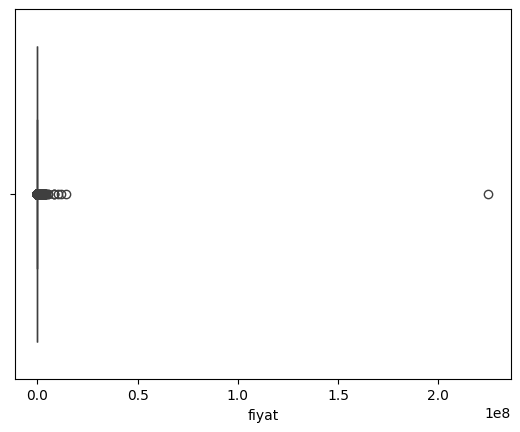

In [264]:
sns.boxplot(x=df_2["fiyat"])
plt.show()

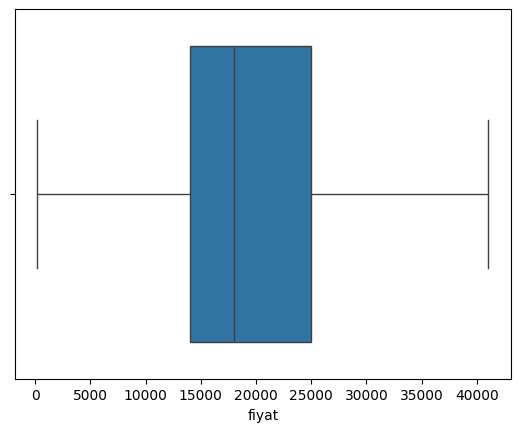

In [265]:
sns.boxplot(x=df3["fiyat"])
plt.show()

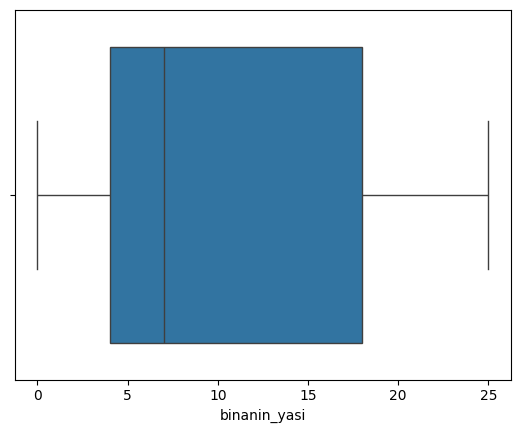

In [266]:
sns.boxplot(x=df_2["binanin_yasi"])
plt.show()

**brut_metrekare ve net_metrekare  için outlier kontrolu yapıyorum**

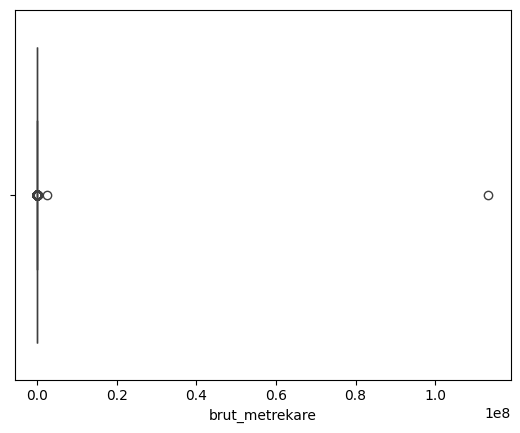

In [267]:
sns.boxplot(x=df_2["brut_metrekare"])
plt.show()

In [268]:
df3 = outliers(df_2, "brut_metrekare")

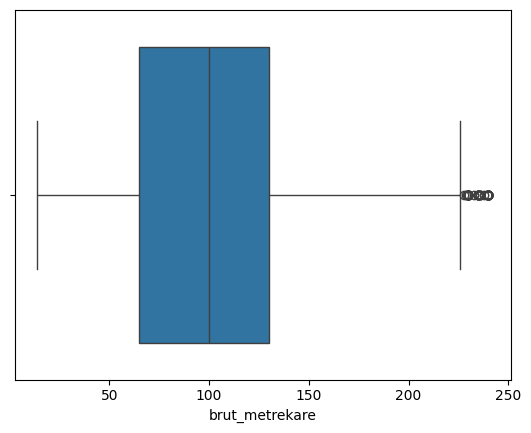

In [269]:
sns.boxplot(x=df3["brut_metrekare"])
plt.show()

In [270]:
Q1 = df3["brut_metrekare"].quantile(0.25)
Q3 = df3["brut_metrekare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [271]:
df3['brut_metrekare'] = np.clip(df3['brut_metrekare'], lower, upper)

C:\Users\onur\AppData\Local\Temp\ipykernel_12756\1193385437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['brut_metrekare'] = np.clip(df3['brut_metrekare'], lower, upper)


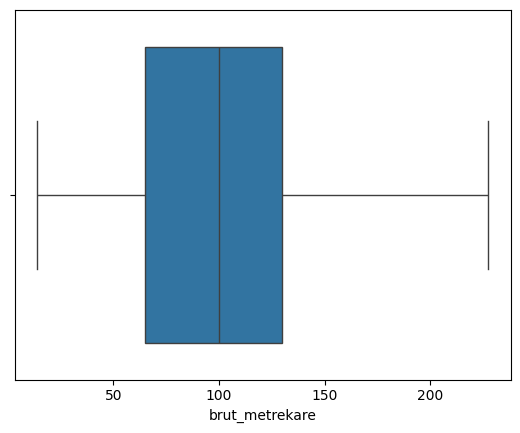

In [272]:
sns.boxplot(x=df3["brut_metrekare"])
plt.show()  

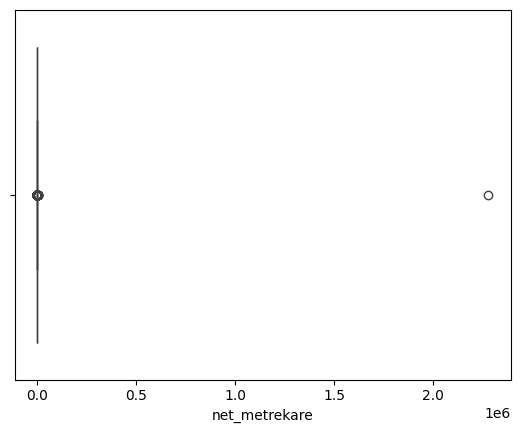

In [273]:
sns.boxplot(x=df_2["net_metrekare"])
plt.show()

In [274]:
df3 = outliers(df_2, "net_metrekare")

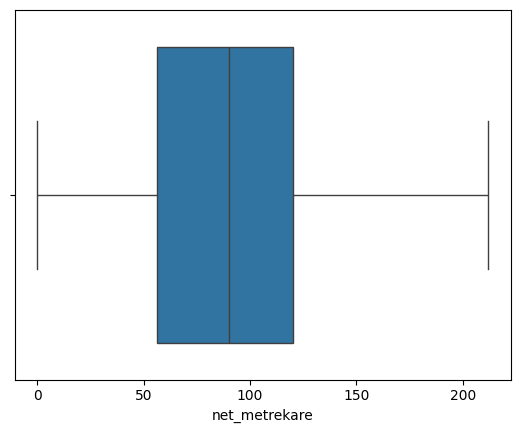

In [275]:
sns.boxplot(x=df3["net_metrekare"])
plt.show()

### Feature Engineering

In [276]:
df3["df1_il"] = df_1["il"]

C:\Users\onur\AppData\Local\Temp\ipykernel_12756\1334052707.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df3["df1_il"] = df_1["il"]
C:\Users\onur\AppData\Local\Temp\ipykernel_12756\1334052707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["df1_il"] = df_1["il"]


In [277]:
df3["df1_ilce"] = df_1["ilce"]

C:\Users\onur\AppData\Local\Temp\ipykernel_12756\90948858.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df3["df1_ilce"] = df_1["ilce"]
C:\Users\onur\AppData\Local\Temp\ipykernel_12756\90948858.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["df1_ilce"] = df_1["ilce"]


In [278]:
df3["df1_mahalle"] = df_1["mahalle"]

C:\Users\onur\AppData\Local\Temp\ipykernel_12756\3801607586.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df3["df1_mahalle"] = df_1["mahalle"]
C:\Users\onur\AppData\Local\Temp\ipykernel_12756\3801607586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["df1_mahalle"] = df_1["mahalle"]


**Her ilin ortalama kira fiyatlarını yeni bir sütunda saklıycam.**

In [279]:
il_ortalama = df3.groupby("df1_il")["fiyat"].mean().reset_index()
il_ortalama.rename(columns={"fiyat" : "il_ortalama"}, inplace=True)
il_ortalama

,df1_il,il_ortalama
0,Adana,233636.637692
1,Adıyaman,14312.500000
2,Afyonkarahisar,23641.142857
3,Aksaray,13352.033708
4,Amasya,25303.012048
...,...,...
72,Çankırı,15178.571429
73,Çorum,75076.923077
74,İstanbul,33965.793651
75,İzmir,29154.141208


In [280]:
df3 = df3.merge(il_ortalama, on="df1_il", how="left")

**Her ilcenin ortalama kira fiyatlarını bir sütunda tutacam**

In [281]:
ilce_ortalama = df3.groupby("df1_ilce")["fiyat"].mean().reset_index()
ilce_ortalama.rename(columns={"fiyat": "ilce_ortalama_kira"}, inplace=True)
ilce_ortalama

,df1_ilce,ilce_ortalama_kira
0,19 Mayıs,18250.000000
1,Acıpayam,12500.000000
2,Adalar,35000.000000
3,Adapazarı,14652.254098
4,Adıyaman Merkez,14312.500000
...,...,...
453,Şereflikoçhisar,18000.000000
454,Şile,34071.428571
455,Şiran,15000.000000
456,Şişli,37358.208955


In [282]:
df3 = df3.merge(ilce_ortalama, on="df1_ilce", how="left")

**Her mahallenin ortalama kira fiyatlarını yeni bir sütunda tutucam**

In [283]:
mahalle_ortalama = df3.groupby('df1_mahalle')['fiyat'].mean().reset_index()
mahalle_ortalama.rename(columns={'fiyat': 'mahalle_ortalama_kira'}, inplace=True)
mahalle_ortalama

,df1_mahalle,mahalle_ortalama_kira
0,1 Nolu Beşirli,25428.571429
1,1 Nolu Bostancı,18900.000000
2,1 Nolu Erdoğdu,10166.666667
3,1. Gündoğan,14500.000000
4,1. Murat,21392.857143
...,...,...
2749,Şirinyalı,56571.428571
2750,Şörhabil,10500.000000
2751,Şükrüpaşa,17355.555556
2752,Şükrüçavuş,21500.000000


In [284]:
df3 = df3.merge(mahalle_ortalama, on="df1_mahalle", how="left")

**oda_basi_alan hesabı yapıyoruz oda_sayisi 0 olan yani olmayan lar için ``division by zero`` hatasının almamak için  0 ları 1 ile değiştirdim.**

In [285]:
df3["oda_basi_alan"] = df3.apply(
    lambda x: x["net_metrekare"] / x["oda"] if x["oda"] > 0 else 1, axis=1
    )

In [286]:
df3["oda_basi_alan"]

0        50.000000
1        46.666667
2        75.000000
3        45.000000
4        46.250000
           ...    
26984    36.000000
26985    70.000000
26986    50.000000
26987     1.000000
26988    45.000000
Name: oda_basi_alan, Length: 26989, dtype: float64

**metrekare_basi_kira hesabı yaptık**

In [287]:
df3["metrekare_basi_kira"] = df3["fiyat"] / df3["net_metrekare"]

In [288]:
df3["metrekare_basi_kira"]

0        110.000000
1        178.571429
2        133.333333
3        266.666667
4        216.216216
            ...    
26984    200.000000
26985    171.428571
26986    150.000000
26987    383.333333
26988    185.185185
Name: metrekare_basi_kira, Length: 26989, dtype: float64

**brüt/ net oranı**

In [289]:
df3["burut_net_orani"] = df3["brut_metrekare"] / df3["net_metrekare"]

In [290]:
df3["burut_net_orani"]

0        1.200000
1        1.250000
2        1.333333
3        1.111111
4        1.081081
           ...   
26984    1.222222
26985    1.142857
26986    1.100000
26987    1.066667
26988    1.074074
Name: burut_net_orani, Length: 26989, dtype: float64

**fiyat / oda_sayisi → oda başına kira değerini bulucaz. oda olmayan yani oda sütunu 0 olan ları 1 ile değiştirdim.**

In [291]:
df3["fiyat_oda_orani"] = df3.apply(
    lambda x: x["fiyat"] / x["oda"] if x["oda"] > 0 else 1, axis=1
)

In [292]:
df3["fiyat_oda_orani"]

0         5500.000000
1         8333.333333
2        10000.000000
3        12000.000000
4        10000.000000
             ...     
26984     7200.000000
26985    12000.000000
26986     7500.000000
26987        1.000000
26988     8333.333333
Name: fiyat_oda_orani, Length: 26989, dtype: float64

**metrekare_basi_kira ve burut_net_orani inf değerleri var bunları silmeliyim**

In [293]:
l = ["mahalle_ortalama_kira","oda_basi_alan","metrekare_basi_kira","burut_net_orani","fiyat_oda_orani",]

inf_rows = df3[np.isinf(df3["metrekare_basi_kira"])]
print(inf_rows)

      net_metrekare  brut_metrekare  binanin_yasi  bulundugu_kat  \
7962              0             110            25              5   

      binanin_kat_sayisi  tapu_durumu  site_icerisinde  banyo_sayisi  fiyat  \
7962                 5.0            8                0             1  18000   

      yapi_durumu  ...  df1_il  df1_ilce  df1_mahalle   il_ortalama  \
7962            1  ...   Bursa  Yıldırım     Namazgah  20596.559322   

      ilce_ortalama_kira  mahalle_ortalama_kira  oda_basi_alan  \
7962        17565.143939           17409.090909            0.0   

      metrekare_basi_kira  burut_net_orani  fiyat_oda_orani  
7962                  inf              inf           9000.0  

[1 rows x 3350 columns]


In [294]:
df3.drop(index=7962, inplace=True)

yeniden outlier bakıcam

In [295]:
def outliers(df,col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[col_name] >= lower_bound) & (df[col_name] <= upper_bound)]

In [296]:
def boxplot_draw(df,col_name):
    sns.boxplot(x=df[col_name])
    plt.show()

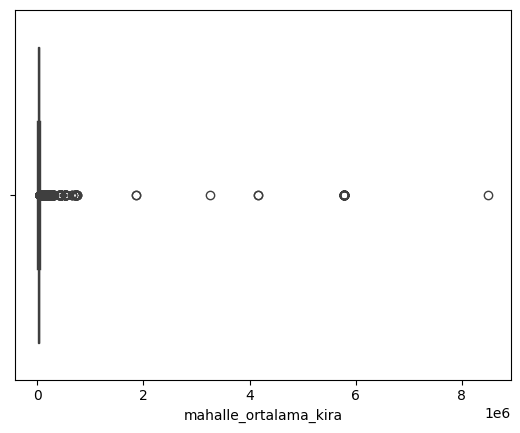

In [297]:
boxplot_draw(df3, "mahalle_ortalama_kira")

In [298]:
# l = ["mahalle_ortalama_kira","oda_basi_alan","metrekare_basi_kira","burut_net_orani","fiyat_oda_orani",]
# for col in l:
#     df3 = outliers(df3, col)

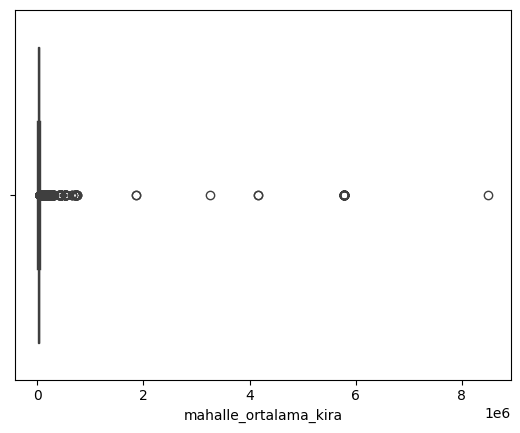

In [299]:
boxplot_draw(df3, "mahalle_ortalama_kira")

In [300]:
outlier_indices = df3[df3['mahalle_ortalama_kira'] >= 35000].index
df3 = df3.drop(outlier_indices)

In [301]:
outlier_indices = df3[df3['mahalle_ortalama_kira'] < 7000].index
df3 = df3.drop(outlier_indices)

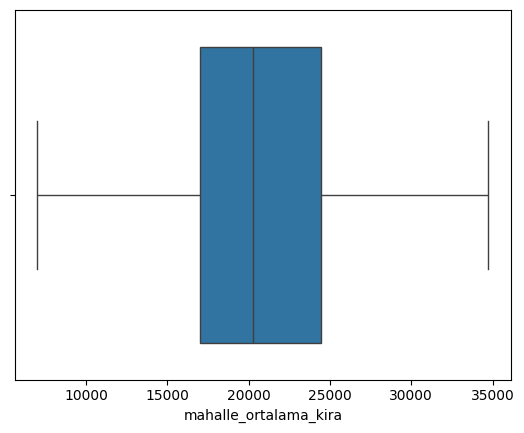

In [302]:
boxplot_draw(df3, "mahalle_ortalama_kira")

In [303]:
df3.to_csv("../data/processed/temiz_turkey_rent.csv", index=False, encoding="utf-8")

## Modelleme

In [304]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# 1. X ve y tanımı
y = df3['fiyat']
X = df3.drop(columns=['fiyat'])

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Hedef değişken log-transform
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 4. Kategorik kolonları belirleme
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# 5. ColumnTransformer ile One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # sayısal kolonları olduğu gibi bırak
)

# 6. Pipeline oluşturma
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=80,
        learning_rate=0.01,
        max_depth=7,
        random_state=42
    ))
])
# max_depth = 5
# n_estimators = 100

# 7. Modeli eğitme
pipeline.fit(X_train, y_train_log)

# 8. Tahmin
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Log dönüşümünü geri al

# 9. Performans değerlendirme
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)
print("RMSE:", rmse)


R² Score: 0.110404372215271
RMSE: 33341.04785395924


In [305]:
y_train_pred_log = pipeline.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("Train R²:", r2_train)
print("Train RMSE:", rmse_train)

Train R²: 0.1383799910545349
Train RMSE: 31473.503776986763


In [306]:
from sklearn.model_selection import cross_val_score

# log-transform edilmiş hedef değişkenle
scores = cross_val_score(pipeline, X, np.log1p(y), cv=5, scoring='r2')
print("CV R²:", scores)
print("CV R² Ortalama:", scores.mean())

CV R²: [0.7787474  0.78153686 0.73707979 0.75934122 0.70120529]
CV R² Ortalama: 0.7515821113041257
